# Multimodal Scene Search System on COCO 2017
## Plain Dense → Cached + Persistent → Hybrid → Reranked → Fallback → OpenAI Scene Explanation

This notebook builds a production-style multimodal retrieval system in stages.

### Main benchmark task
- **Text → Image retrieval**

### Additional supported capabilities
- **Image → Image retrieval**
- **Image → Text evidence retrieval**
- **Scene explanation from retrieved evidence using OpenAI**

### System stages
1. Dataset loading and preparation
2. Plain dense retrieval with OpenCLIP
3. Embedding caching + persistent vector DB
4. Hybrid retrieval (Dense + BM25)
5. Cross-encoder reranking
6. Graceful degradation / fallback pipeline
7. OpenAI scene explanation with few-shot prompting
8. Final evaluation and comparison plots

### Main metrics
- Recall@1
- Recall@5
- MRR
- Precision@5
- nDCG@5
- Median latency
- Stage-wise latency breakdown

Dataset: COCO 2017  
Environment: Kaggle Notebook  
GPU: Recommended

In [ ]:
!pip -q install open_clip_torch chromadb rank_bm25 sentence-transformers transformers accelerate openai langchain langchain-openai

In [ ]:
!pip -q install \
open_clip_torch \
chromadb \
rank_bm25 \
sentence-transformers \
transformers \
accelerate \
openai \
langchain \
langchain-openai \
torch \
numpy \
pillow \
matplotlib

In [1]:
import os
import gc
import re
import json
import time
import math
import pickle
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

import open_clip
import chromadb
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder
from openai import OpenAI

from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.tools import tool
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

In [2]:
import os
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
OPENAI_API_KEY = user_secrets.get_secret("OPENAI_API_KEY")

assert OPENAI_API_KEY, "OPENAI_API_KEY not found."

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

print("OpenAI key loaded successfully.")


OpenAI key loaded successfully.


In [3]:
# Global config
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# -------------------------
# Kaggle dataset paths
# -------------------------
DATASET_ROOT = Path("/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017")

VAL_IMG_DIR = DATASET_ROOT / "val2017"
ANN_DIR = DATASET_ROOT / "annotations"
CAPTION_JSON = ANN_DIR / "captions_val2017.json"

print("VAL_IMG_DIR exists:", VAL_IMG_DIR.exists())
print("CAPTION_JSON exists:", CAPTION_JSON.exists())

# -------------------------
# Experiment controls
# -------------------------
MAX_IMAGES = 3000
TOP_K_EVAL = 5
BATCH_SIZE = 64
EVAL_SAMPLES = 300

# -------------------------
# Cache / persistence dirs
# -------------------------
CACHE_DIR = Path("./cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CHROMA_DIR = Path("./chroma_db")
CHROMA_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Models
# -------------------------
#CLIP_MODEL_NAME = "ViT-B-32"
#CLIP_PRETRAINED = "openai"
CLIP_MODEL_NAME = "ViT-L-14"
CLIP_PRETRAINED = "openai"
RERANK_MODEL_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"

OPENAI_MODEL = "gpt-4o-mini"

# Now the key should exist
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")

print("OpenAI key found:", OPENAI_API_KEY is not None)

DEVICE: cuda
VAL_IMG_DIR exists: True
CAPTION_JSON exists: True
OpenAI key found: True


## Stage 0 — Load COCO captions and build image-level metadata

We build:

- image_id → file_name mapping
- caption dataframe
- image-level grouped captions
- evaluation queries

The evaluation task is:

**Query caption → retrieve correct image**

In [4]:
import json

with open(CAPTION_JSON, "r") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]

print("Total images:", len(images))
print("Total captions:", len(annotations))

Total images: 5000
Total captions: 25014


In [5]:
# Build caption rows

image_id_to_file = {img["id"]: img["file_name"] for img in images}

rows = []

for ann in annotations:
    
    image_id = ann["image_id"]
    caption = ann["caption"].strip()

    file_name = image_id_to_file.get(image_id)

    if file_name is None:
        continue

    image_path = VAL_IMG_DIR / file_name

    if image_path.exists():
        rows.append({
            "image_id": image_id,
            "file_name": file_name,
            "image_path": str(image_path),
            "caption": caption
        })

df = pd.DataFrame(rows)

print("Rows:", df.shape)
df.head()

Rows: (25014, 4)


,image_id,file_name,image_path,caption
0,179765,000000179765.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,A black Honda motorcycle parked in front of a ...
1,179765,000000179765.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,A Honda motorcycle parked in a grass driveway
2,190236,000000190236.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,An office cubicle with four different types of...
3,331352,000000331352.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,A small closed toilet in a cramped space.
4,517069,000000517069.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,Two women waiting at a bench next to a street.


In [6]:
#Aggregate captions per image
image_group = (
    df.groupby(["image_id", "file_name", "image_path"])["caption"]
    .apply(list)
    .reset_index()
)

# join all 5 captions into one document
image_group["joined_caption"] = image_group["caption"].apply(lambda x: " ".join(x))

print("Images after grouping:", image_group.shape)

image_group.head()

Images after grouping: (5000, 5)


,image_id,file_name,image_path,caption,joined_caption
0,139,000000000139.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,[A woman stands in the dining area at the tabl...,A woman stands in the dining area at the table...
1,285,000000000285.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,[A big burly grizzly bear is show with grass i...,A big burly grizzly bear is show with grass in...
2,632,000000000632.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,"[Bedroom scene with a bookcase, blue comforter...","Bedroom scene with a bookcase, blue comforter ..."
3,724,000000000724.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,[A stop sign is mounted upside-down on it's po...,A stop sign is mounted upside-down on it's pos...
4,776,000000000776.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,"[Three teddy bears, each a different color, sn...","Three teddy bears, each a different color, snu..."


In [7]:
# Prepare lists aligned with embeddings

image_paths = image_group["image_path"].tolist()
captions = image_group["joined_caption"].tolist()

print("Images:", len(image_paths))
print("Captions:", len(captions))

Images: 5000
Captions: 5000


In [8]:
#Build evaluation dataframe
# Use one caption per image as a query
eval_df = (
    df.groupby("image_id")
    .first()[["file_name", "image_path", "caption"]]
    .reset_index()
    .rename(columns={"caption": "query"})
)

print(eval_df.shape)
eval_df.head()

(5000, 4)


,image_id,file_name,image_path,query
0,139,000000000139.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,A woman stands in the dining area at the table.
1,285,000000000285.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,A big burly grizzly bear is show with grass in...
2,632,000000000632.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,"Bedroom scene with a bookcase, blue comforter ..."
3,724,000000000724.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,A stop sign is mounted upside-down on it's post.
4,776,000000000776.jpg,/kaggle/input/datasets/awsaf49/coco-2017-datas...,"Three teddy bears, each a different color, snu..."


## Stage 1 — Load OpenCLIP and define the baseline dense retrieval system

This is the plain baseline:

Query text  
→ CLIP text embedding  
→ cosine similarity against image embeddings  
→ top-k images

In [9]:
#Load OpenCLIP model
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    CLIP_MODEL_NAME,
    pretrained=CLIP_PRETRAINED
)
clip_model = clip_model.to(DEVICE).eval()
clip_tokenizer = open_clip.get_tokenizer(CLIP_MODEL_NAME)

print("Loaded CLIP:", CLIP_MODEL_NAME, CLIP_PRETRAINED)

open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loaded CLIP: ViT-L-14 openai


In [10]:
model = clip_model
preprocess = clip_preprocess
tokenizer = clip_tokenizer

In [11]:
#Helper utilities
def l2_normalize_np(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)

def safe_open_image(path):
    return Image.open(path).convert("RGB")

def bm25_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

def cosine_topk(query_emb, matrix_emb, top_k=5):
    scores = matrix_emb @ query_emb
    idx = np.argsort(-scores)[:top_k]
    return idx, scores[idx]

def dcg_at_k(relevances, k):
    relevances = np.asarray(relevances)[:k]
    if len(relevances) == 0:
        return 0.0
    return np.sum((2 ** relevances - 1) / np.log2(np.arange(2, len(relevances) + 2)))

def ndcg_at_k(pred_ids, gt_id, k=5):
    relevances = [1 if pid == gt_id else 0 for pid in pred_ids[:k]]
    ideal = [1] + [0] * (k - 1)
    denom = dcg_at_k(ideal, k)
    if denom == 0:
        return 0.0
    return dcg_at_k(relevances, k) / denom

In [12]:
#encode functions 
def encode_images(image_paths, batch_size=64):
    outputs = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Encoding images"):
        batch_paths = image_paths[i:i+batch_size]
        batch_imgs = []
        for p in batch_paths:
            img = safe_open_image(p)
            batch_imgs.append(clip_preprocess(img))
        batch_imgs = torch.stack(batch_imgs).to(DEVICE)

        with torch.no_grad():
            feats = clip_model.encode_image(batch_imgs)
            feats = F.normalize(feats, dim=-1)

        outputs.append(feats.cpu().numpy())

        del batch_imgs, feats
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    return np.vstack(outputs)

def encode_texts(texts, batch_size=64):
    outputs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding texts"):
        batch_texts = texts[i:i+batch_size]
        tokens = clip_tokenizer(batch_texts).to(DEVICE)

        with torch.no_grad():
            feats = clip_model.encode_text(tokens)
            feats = F.normalize(feats, dim=-1)

        outputs.append(feats.cpu().numpy())

        del tokens, feats
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    return np.vstack(outputs)

In [13]:
#Stage 1 metadata arrays
image_ids = image_group["image_id"].tolist()
image_paths = image_group["image_path"].tolist()
image_texts = image_group["joined_caption"].tolist()

print("Num image docs:", len(image_ids))

Num image docs: 5000


In [14]:
#Compute baseline embeddings
stage1_start = time.time()

image_embs = encode_images(image_paths, batch_size=BATCH_SIZE)
text_embs = encode_texts(image_texts, batch_size=BATCH_SIZE)

stage1_time = time.time() - stage1_start

print("image_embs:", image_embs.shape)
print("text_embs :", text_embs.shape)
print("Stage 1 embedding build time (sec):", round(stage1_time, 2))

Encoding images:   0%|          | 0/79 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/79 [00:00<?, ?it/s]

image_embs: (5000, 768)
text_embs : (5000, 768)
Stage 1 embedding build time (sec): 383.42


In [15]:
#Compute baseline embeddings
stage1_start = time.time()

image_embs = encode_images(image_paths, batch_size=BATCH_SIZE)
text_embs = encode_texts(image_texts, batch_size=BATCH_SIZE)

stage1_time = time.time() - stage1_start

print("image_embs:", image_embs.shape)
print("text_embs :", text_embs.shape)
print("Stage 1 embedding build time (sec):", round(stage1_time, 2))

Encoding images:   0%|          | 0/79 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/79 [00:00<?, ?it/s]

image_embs: (5000, 768)
text_embs : (5000, 768)
Stage 1 embedding build time (sec): 359.41


In [16]:
#Plain dense retrieval
def retrieve_text_to_image_plain(query, top_k=5):
    q_emb = encode_texts([query], batch_size=1)[0]
    idx, scores = cosine_topk(q_emb, image_embs, top_k=top_k)

    results = []
    for rank, (i, s) in enumerate(zip(idx, scores), start=1):
        results.append({
            "rank": rank,
            "image_id": image_ids[i],
            "image_path": image_paths[i],
            "caption": image_texts[i],
            "score": float(s),
            "retrieval_stage": "plain_dense"
        })
    return results

In [17]:
#Image→Text evidence retrieval
def retrieve_image_to_text(query_image_path, top_k=5):
    q_emb = encode_images([query_image_path], batch_size=1)[0]
    idx, scores = cosine_topk(q_emb, text_embs, top_k=top_k)

    results = []
    for rank, (i, s) in enumerate(zip(idx, scores), start=1):
        results.append({
            "rank": rank,
            "image_id": image_ids[i],
            "image_path": image_paths[i],
            "caption": image_texts[i],
            "score": float(s),
            "retrieval_stage": "image_to_text"
        })
    return results

In [18]:
#Visualization helper


# Visualization helper
def show_image_results(results, title="Results"):
    n = len(results)
    plt.figure(figsize=(14, 4 * n))
    for i, r in enumerate(results, 1):
        img = safe_open_image(r["image_path"])
        plt.subplot(n, 1, i)
        plt.imshow(img)
        plt.axis("off")

        base_score = r.get("score", None)
        audit_score = r.get("audit_score", None)
        verdict = r.get("audit_verdict", None)

        score_text = ""
        if isinstance(base_score, (int, float)):
            score_text += f"Retrieval={base_score:.4f}"
        if isinstance(audit_score, (int, float)):
            if score_text:
                score_text += " | "
            score_text += f"Audit={audit_score:.1f}"
        if verdict:
            score_text += f" | verdict={verdict}"

        plt.title(
            f"Rank {r['rank']} | {score_text}\n{r['caption'][:180]}",
            fontsize=10
        )

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [19]:
# -------------------------------------------------------
# Image → Image retrieval (CLIP similarity)
# -------------------------------------------------------

def retrieve_image_to_image(query_image_path, top_k=5):

    img = Image.open(query_image_path).convert("RGB")
    img_tensor = preprocess(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        query_emb = model.encode_image(img_tensor)
        query_emb = query_emb / query_emb.norm(dim=-1, keepdim=True)

    # ensure embeddings are torch tensor on same device
    if isinstance(image_embs, np.ndarray):
        db_embs = torch.tensor(image_embs).to(DEVICE)
    else:
        db_embs = image_embs.to(DEVICE)

    sims = (query_emb @ db_embs.T).squeeze(0).cpu().numpy()

    top_idx = np.argsort(-sims)[:top_k]

    results = []

    for rank, idx in enumerate(top_idx, 1):
        results.append({
            "rank": rank,
            "score": float(sims[idx]),
            "image_path": image_paths[idx],
            "caption": captions[idx]
        })

    return results

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

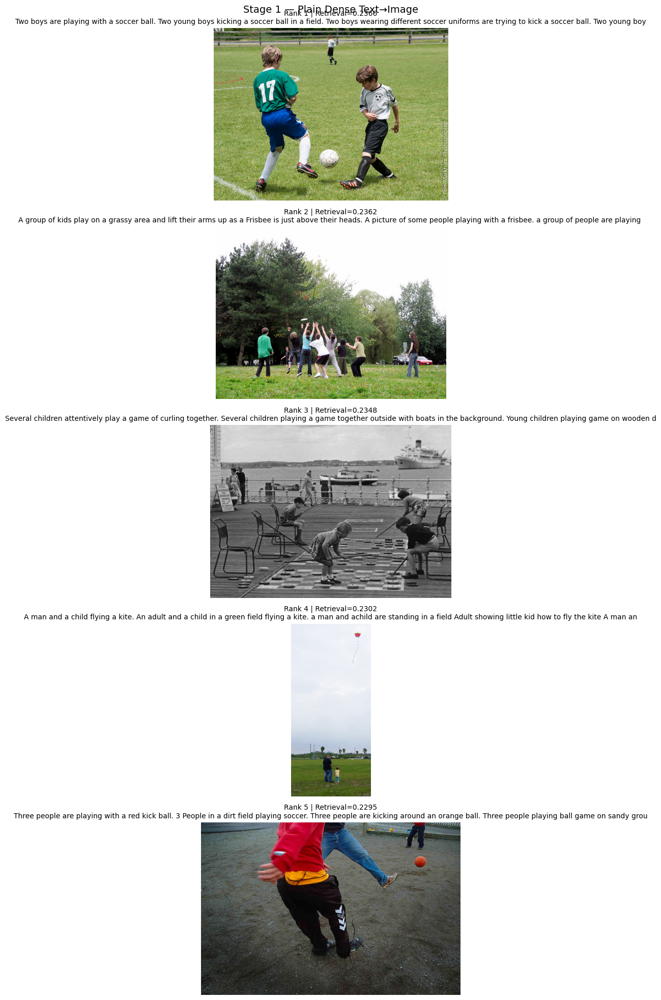

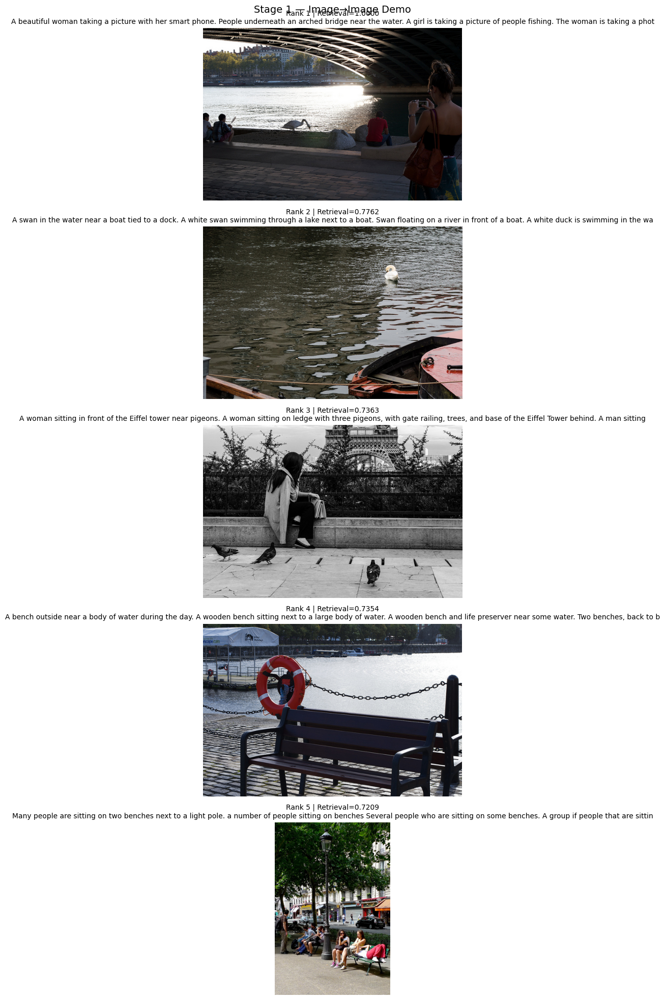

Encoding images:   0%|          | 0/1 [00:00<?, ?it/s]

Rank 1 | Score=0.2730
A beautiful woman taking a picture with her smart phone. People underneath an arched bridge near the water. A girl is taking a picture of people fishing. The woman is taking a photo of the white goose next to the river. A waterway under a bridge with
--------------------------------------------------------------------------------
Rank 2 | Score=0.2264
A swan in the water near a boat tied to a dock. A white swan swimming through a lake next to a boat. Swan floating on a river in front of a boat. A white duck is swimming in the water near a boat. A white swan is swimming near a docked boat.
--------------------------------------------------------------------------------
Rank 3 | Score=0.2058
A woman taking pictures on a busy street. A woman taking a picture on a sunny day. A male and a female holding up their cellphones A woman taking a picture up at the sky with her phone. A woman holding a camera is taking a picture.
-----------------------------------------------

In [20]:
#Demo baseline retrievals
demo_query = "children playing football outdoors"
plain_demo = retrieve_text_to_image_plain(demo_query, top_k=5)
show_image_results(plain_demo, title="Stage 1 — Plain Dense Text→Image")

sample_img = image_paths[10]
img2img_demo = retrieve_image_to_image(sample_img, top_k=5)
show_image_results(img2img_demo, title="Stage 1 — Image→Image Demo")

img2txt_demo = retrieve_image_to_text(sample_img, top_k=3)
for r in img2txt_demo:
    print(f"Rank {r['rank']} | Score={r['score']:.4f}")
    print(r["caption"][:250])
    print("-" * 80)

### Stage 1 Evaluation — Plain Dense Baseline

We evaluate the baseline on:
- Recall@1
- Recall@5
- MRR
- Precision@5
- nDCG@5
- Median latency

In [21]:
#Metric helpers
def compute_recall_at_k(pred_ids, gt_id, k):
    return 1.0 if gt_id in pred_ids[:k] else 0.0

def compute_precision_at_k(pred_ids, gt_id, k):
    rel = sum(1 for pid in pred_ids[:k] if pid == gt_id)
    return rel / k

def compute_mrr(pred_ids, gt_id):
    for i, pid in enumerate(pred_ids, start=1):
        if pid == gt_id:
            return 1.0 / i
    return 0.0

In [22]:
#Metric helpers
def compute_recall_at_k(pred_ids, gt_id, k):
    return 1.0 if gt_id in pred_ids[:k] else 0.0

def compute_precision_at_k(pred_ids, gt_id, k):
    rel = sum(1 for pid in pred_ids[:k] if pid == gt_id)
    return rel / k

def compute_mrr(pred_ids, gt_id):
    for i, pid in enumerate(pred_ids, start=1):
        if pid == gt_id:
            return 1.0 / i
    return 0.0

In [23]:
#evaluate wrapper
def evaluate_system(eval_df, retrieval_fn, top_k=5, n_samples=300):
    sample_eval = eval_df.sample(min(n_samples, len(eval_df)), random_state=SEED).reset_index(drop=True)

    recall1_list = []
    recall5_list = []
    mrr_list = []
    precision5_list = []
    ndcg5_list = []
    latency_list = []

    for _, row in tqdm(sample_eval.iterrows(), total=len(sample_eval), desc="Evaluating"):
        query = row["query"]
        gt_id = row["image_id"]

        start = time.time()
        pred_ids = retrieval_fn(query, top_k=top_k)
        latency = time.time() - start

        recall1_list.append(compute_recall_at_k(pred_ids, gt_id, 1))
        recall5_list.append(compute_recall_at_k(pred_ids, gt_id, min(5, top_k)))
        mrr_list.append(compute_mrr(pred_ids, gt_id))
        precision5_list.append(compute_precision_at_k(pred_ids, gt_id, min(5, top_k)))
        ndcg5_list.append(ndcg_at_k(pred_ids, gt_id, k=min(5, top_k)))
        latency_list.append(latency)

    return {
        "recall@1": float(np.mean(recall1_list)),
        "recall@5": float(np.mean(recall5_list)),
        "mrr": float(np.mean(mrr_list)),
        "precision@5": float(np.mean(precision5_list)),
        "ndcg@5": float(np.mean(ndcg5_list)),
        "latency_median_sec": float(np.median(latency_list)),
        "latency_mean_sec": float(np.mean(latency_list)),
        "num_samples": len(sample_eval)
    }

In [24]:
#Plain baseline eval
def plain_pred_ids(query, top_k=5):
    return [r["image_id"] for r in retrieve_text_to_image_plain(query, top_k=top_k)]

stage1_metrics = evaluate_system(eval_df, plain_pred_ids, top_k=TOP_K_EVAL, n_samples=EVAL_SAMPLES)
stage1_metrics

Evaluating:   0%|          | 0/300 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

...

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

{'recall@1': 0.36666666666666664,
 'recall@5': 0.6466666666666666,
 'mrr': 0.47377777777777774,
 'precision@5': 0.12933333333333333,
 'ndcg@5': 0.5170580248914174,
 'latency_median_sec': 0.4366708993911743,
 'latency_mean_sec': 0.4358195479710897,
 'num_samples': 300}

## Stage 2 — Embedding caching + persistent vector database

This stage improves system design, reproducibility, and startup efficiency.

Changes:
- Save embeddings to disk
- Reuse cached arrays
- Store vectors in persistent ChromaDB

This stage is mostly a **systems improvement**, so retrieval quality should remain the same, but setup and serving become more production-like.

In [25]:
#Cache paths
img_cache_path = CACHE_DIR / f"image_embs_{MAX_IMAGES}.npy"
txt_cache_path = CACHE_DIR / f"text_embs_{MAX_IMAGES}.npy"
meta_cache_path = CACHE_DIR / f"meta_{MAX_IMAGES}.pkl"

In [26]:
#Cache paths
img_cache_path = CACHE_DIR / f"image_embs_{MAX_IMAGES}.npy"
txt_cache_path = CACHE_DIR / f"text_embs_{MAX_IMAGES}.npy"
meta_cache_path = CACHE_DIR / f"meta_{MAX_IMAGES}.pkl"

In [27]:
#Save cache
np.save(img_cache_path, image_embs)
np.save(txt_cache_path, text_embs)

with open(meta_cache_path, "wb") as f:
    pickle.dump({
        "image_ids": image_ids,
        "image_paths": image_paths,
        "image_texts": image_texts
    }, f)

print("Saved cache:")
print(img_cache_path)
print(txt_cache_path)
print(meta_cache_path)

Saved cache:
cache/image_embs_3000.npy
cache/text_embs_3000.npy
cache/meta_3000.pkl


In [28]:
#Persistent Chroma collection
chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))
collection_name = f"coco_images_{MAX_IMAGES}"

existing_names = [c.name for c in chroma_client.list_collections()]

if collection_name in existing_names:
    image_collection = chroma_client.get_collection(collection_name)
    print("Loaded existing collection:", collection_name)
else:
    image_collection = chroma_client.create_collection(collection_name)
    print("Created collection:", collection_name)

Loaded existing collection: coco_images_3000


In [29]:
#Upsert vectors into Chroma if needed
if image_collection.count() == 0:
    batch_size_db = 500
    for i in tqdm(range(0, len(image_ids), batch_size_db), desc="Adding to Chroma"):
        batch_ids = [str(x) for x in image_ids[i:i+batch_size_db]]
        batch_embs = image_embs[i:i+batch_size_db].tolist()
        batch_docs = image_texts[i:i+batch_size_db]
        batch_meta = [{"image_path": image_paths[j]} for j in range(i, min(i+batch_size_db, len(image_ids)))]

        image_collection.add(
            ids=batch_ids,
            embeddings=batch_embs,
            documents=batch_docs,
            metadatas=batch_meta
        )

print("Chroma count:", image_collection.count())

Chroma count: 5000


In [30]:
#Dense retrieval through Chroma
def retrieve_text_to_image_chroma(query, top_k=5):
    q_emb = encode_texts([query], batch_size=1)[0].tolist()

    out = image_collection.query(
        query_embeddings=[q_emb],
        n_results=top_k
    )

    ids_out = out["ids"][0]
    docs_out = out["documents"][0]
    meta_out = out["metadatas"][0]

    results = []
    for rank, (img_id, doc, meta) in enumerate(zip(ids_out, docs_out, meta_out), start=1):
        results.append({
            "rank": rank,
            "image_id": int(img_id),
            "image_path": meta["image_path"],
            "caption": doc,
            "score": None,
            "retrieval_stage": "dense_chroma"
        })
    return results

In [31]:
#Stage 2 eval
def chroma_pred_ids(query, top_k=5):
    return [r["image_id"] for r in retrieve_text_to_image_chroma(query, top_k=top_k)]

stage2_metrics = evaluate_system(eval_df, chroma_pred_ids, top_k=TOP_K_EVAL, n_samples=EVAL_SAMPLES)
stage2_metrics

Evaluating:   0%|          | 0/300 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

...

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

{'recall@1': 0.36333333333333334,
 'recall@5': 0.6433333333333333,
 'mrr': 0.47061111111111115,
 'precision@5': 0.12866666666666665,
 'ndcg@5': 0.5138707707275469,
 'latency_median_sec': 0.432086706161499,
 'latency_mean_sec': 0.4322503844896952,
 'num_samples': 300}

In [32]:
#Stage 2 system metrics
cache_load_time = 0
stage2_system_metrics = {
    "embedding_build_time_sec": round(stage1_time, 2),
    "cache_load_time_sec": round(cache_load_time, 3),
    "chroma_count": image_collection.count()
}
stage2_system_metrics

{'embedding_build_time_sec': 359.41,
 'cache_load_time_sec': 0,
 'chroma_count': 5000}

In [33]:
#Stage 2 system metrics
stage2_system_metrics = {
    "embedding_build_time_sec": round(stage1_time, 2),
    "cache_load_time_sec": round(cache_load_time, 3),
    "chroma_count": image_collection.count()
}
stage2_system_metrics

{'embedding_build_time_sec': 359.41,
 'cache_load_time_sec': 0,
 'chroma_count': 5000}

In [34]:
#Build BM25 corpus
bm25_corpus = [bm25_tokenize(t) for t in image_texts]
bm25 = BM25Okapi(bm25_corpus)

print("BM25 corpus size:", len(bm25_corpus))

BM25 corpus size: 5000


In [35]:
#Hybrid retrieval function
def retrieve_text_to_image_hybrid(query, top_k=5, dense_weight=0.7, bm25_weight=0.3, candidate_k=50):
    q_emb = encode_texts([query], batch_size=1)[0]
    dense_scores = image_embs @ q_emb

    tokenized_query = bm25_tokenize(query)
    bm25_scores = np.array(bm25.get_scores(tokenized_query))

    # min-max normalize
    dense_norm = (dense_scores - dense_scores.min()) / (dense_scores.max() - dense_scores.min() + 1e-12)
    bm25_norm = (bm25_scores - bm25_scores.min()) / (bm25_scores.max() - bm25_scores.min() + 1e-12)

    hybrid_scores = dense_weight * dense_norm + bm25_weight * bm25_norm
    idx = np.argsort(-hybrid_scores)[:candidate_k]

    results = []
    for rank, i in enumerate(idx[:top_k], start=1):
        results.append({
            "rank": rank,
            "image_id": image_ids[i],
            "image_path": image_paths[i],
            "caption": image_texts[i],
            "score": float(hybrid_scores[i]),
            "dense_score": float(dense_scores[i]),
            "bm25_score": float(bm25_scores[i]),
            "index": i,
            "retrieval_stage": "hybrid"
        })

    return results

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

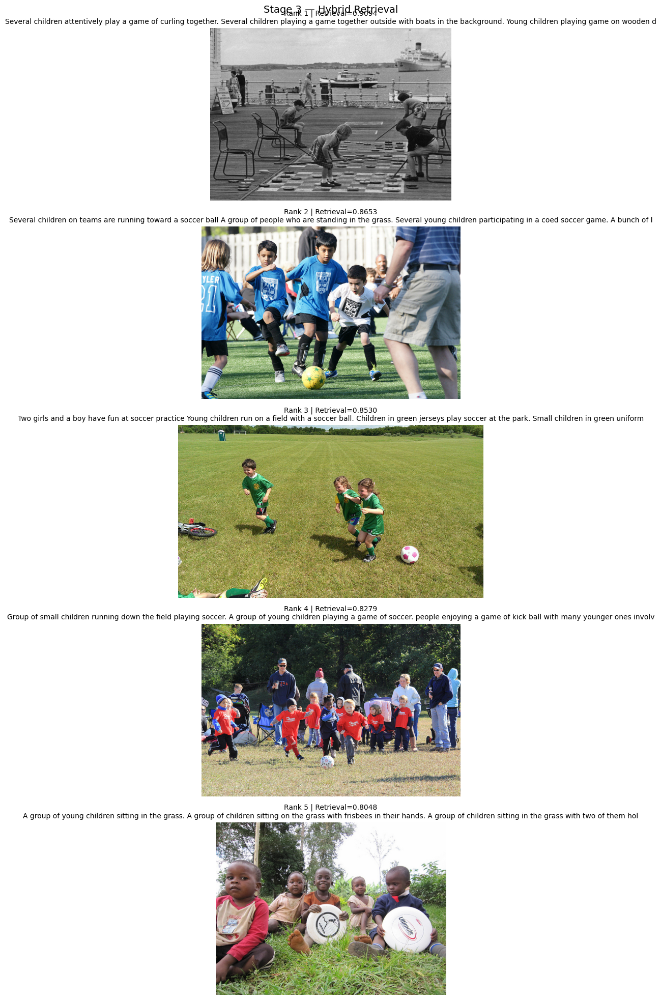

In [36]:
#Hybrid demo
hybrid_demo = retrieve_text_to_image_hybrid(demo_query, top_k=5)
show_image_results(hybrid_demo, title="Stage 3 — Hybrid Retrieval")

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

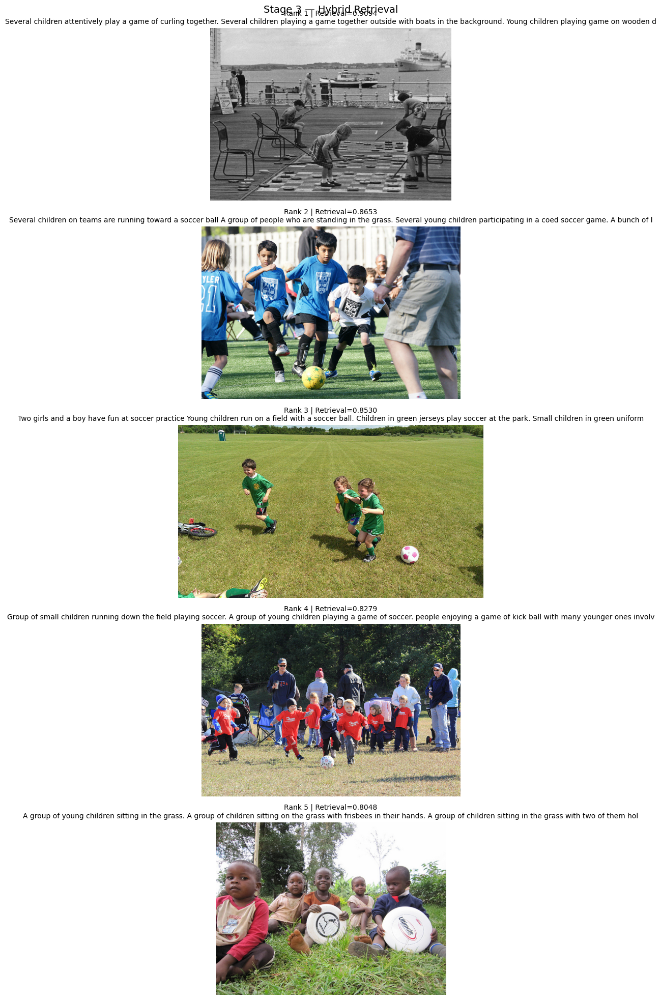

In [37]:
#Hybrid demo
hybrid_demo = retrieve_text_to_image_hybrid(demo_query, top_k=5)
show_image_results(hybrid_demo, title="Stage 3 — Hybrid Retrieval")

In [38]:
def hybrid_pred_ids(query, top_k=5):
    return [r["image_id"] for r in retrieve_text_to_image_hybrid(query, top_k=top_k)]

stage3_metrics = evaluate_system(eval_df, hybrid_pred_ids, top_k=TOP_K_EVAL, n_samples=EVAL_SAMPLES)
stage3_metrics

Evaluating:   0%|          | 0/300 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

...

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

{'recall@1': 0.8,
 'recall@5': 0.9166666666666666,
 'mrr': 0.8450555555555556,
 'precision@5': 0.18333333333333332,
 'ndcg@5': 0.8630036671297739,
 'latency_median_sec': 0.4942138195037842,
 'latency_mean_sec': 0.4944368147850037,
 'num_samples': 300}

## Stage 4 — Cross-encoder reranking

Now we use a stronger relevance model to rerank the top candidates from hybrid retrieval.

Pipeline:
Query
→ hybrid retrieval top-N
→ cross-encoder scores query-caption pairs
→ reranked final results

In [39]:
#Load reranker
reranker = CrossEncoder(RERANK_MODEL_NAME, device=DEVICE)
print("Loaded reranker:", RERANK_MODEL_NAME)

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Loaded reranker: cross-encoder/ms-marco-MiniLM-L-6-v2


In [40]:
#Hybrid + rerank function
def retrieve_text_to_image_reranked(query, top_k=5, dense_weight=0.7, bm25_weight=0.3, candidate_k=30):
    q_emb = encode_texts([query], batch_size=1)[0]
    dense_scores = image_embs @ q_emb

    tokenized_query = bm25_tokenize(query)
    bm25_scores = np.array(bm25.get_scores(tokenized_query))

    dense_norm = (dense_scores - dense_scores.min()) / (dense_scores.max() - dense_scores.min() + 1e-12)
    bm25_norm = (bm25_scores - bm25_scores.min()) / (bm25_scores.max() - bm25_scores.min() + 1e-12)
    hybrid_scores = dense_weight * dense_norm + bm25_weight * bm25_norm

    candidate_idx = np.argsort(-hybrid_scores)[:candidate_k]

    pairs = [[query, image_texts[i]] for i in candidate_idx]
    rerank_scores = reranker.predict(pairs, show_progress_bar=False)

    reranked = sorted(
        zip(candidate_idx, rerank_scores, hybrid_scores[candidate_idx]),
        key=lambda x: x[1],
        reverse=True
    )

    results = []
    for rank, (i, rerank_score, hybrid_score) in enumerate(reranked[:top_k], start=1):
        results.append({
            "rank": rank,
            "image_id": image_ids[i],
            "image_path": image_paths[i],
            "caption": image_texts[i],
            "score": float(rerank_score),
            "hybrid_score": float(hybrid_score),
            "index": i,
            "retrieval_stage": "hybrid_reranked"
        })

    return results

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

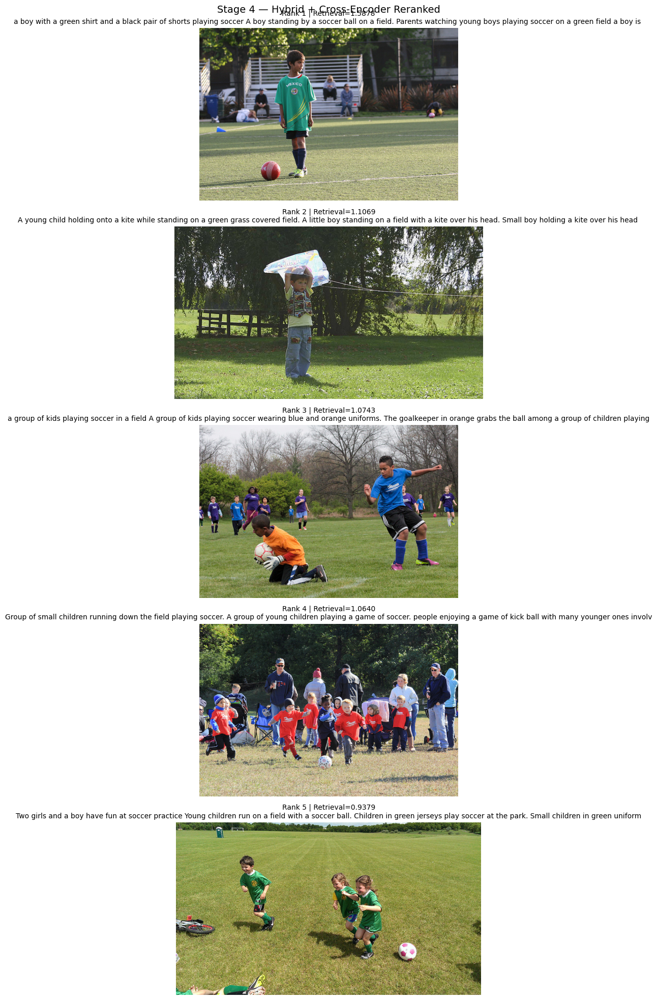

In [41]:
#Reranked demo
reranked_demo = retrieve_text_to_image_reranked(demo_query, top_k=5)
show_image_results(reranked_demo, title="Stage 4 — Hybrid + Cross-Encoder Reranked")

In [42]:
#Stage 4 eval
def reranked_pred_ids(query, top_k=5):
    return [r["image_id"] for r in retrieve_text_to_image_reranked(query, top_k=top_k)]

stage4_metrics = evaluate_system(eval_df, reranked_pred_ids, top_k=TOP_K_EVAL, n_samples=EVAL_SAMPLES)
stage4_metrics

Evaluating:   0%|          | 0/300 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

...

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

{'recall@1': 0.9633333333333334,
 'recall@5': 0.9833333333333333,
 'mrr': 0.9716666666666667,
 'precision@5': 0.19666666666666666,
 'ndcg@5': 0.974616907101442,
 'latency_median_sec': 0.5864639282226562,
 'latency_mean_sec': 0.5851342105865478,
 'num_samples': 300}

## Stage 5 — Graceful degradation / fallback pipeline

This stage adds production-style fault tolerance.

Fallback order:
1. Try hybrid + reranking
2. If reranker fails, return hybrid results
3. If hybrid fails, return plain dense results
4. If dense retrieval fails, return BM25-only results

In [43]:
#BM25-only retrieval
def retrieve_text_to_image_bm25_only(query, top_k=5):
    bm25_scores = np.array(bm25.get_scores(bm25_tokenize(query)))
    idx = np.argsort(-bm25_scores)[:top_k]

    results = []
    for rank, i in enumerate(idx, start=1):
        results.append({
            "rank": rank,
            "image_id": image_ids[i],
            "image_path": image_paths[i],
            "caption": image_texts[i],
            "score": float(bm25_scores[i]),
            "retrieval_stage": "bm25_only"
        })
    return results

In [44]:
#BM25-only retrieval
def retrieve_text_to_image_bm25_only(query, top_k=5):
    bm25_scores = np.array(bm25.get_scores(bm25_tokenize(query)))
    idx = np.argsort(-bm25_scores)[:top_k]

    results = []
    for rank, i in enumerate(idx, start=1):
        results.append({
            "rank": rank,
            "image_id": image_ids[i],
            "image_path": image_paths[i],
            "caption": image_texts[i],
            "score": float(bm25_scores[i]),
            "retrieval_stage": "bm25_only"
        })
    return results

In [45]:
#Fallback retrieval pipeline
def retrieve_with_fallback(query, top_k=5):
    trace = []

    try:
        start = time.time()
        results = retrieve_text_to_image_reranked(query, top_k=top_k)
        trace.append(("reranked", time.time() - start))
        return results, trace
    except Exception as e:
        trace.append((f"reranked_failed: {str(e)[:120]}", None))

    try:
        start = time.time()
        results = retrieve_text_to_image_hybrid(query, top_k=top_k)
        trace.append(("hybrid_fallback", time.time() - start))
        return results, trace
    except Exception as e:
        trace.append((f"hybrid_failed: {str(e)[:120]}", None))

    try:
        start = time.time()
        results = retrieve_text_to_image_plain(query, top_k=top_k)
        trace.append(("plain_dense_fallback", time.time() - start))
        return results, trace
    except Exception as e:
        trace.append((f"plain_failed: {str(e)[:120]}", None))

    start = time.time()
    results = retrieve_text_to_image_bm25_only(query, top_k=top_k)
    trace.append(("bm25_last_resort", time.time() - start))
    return results, trace

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

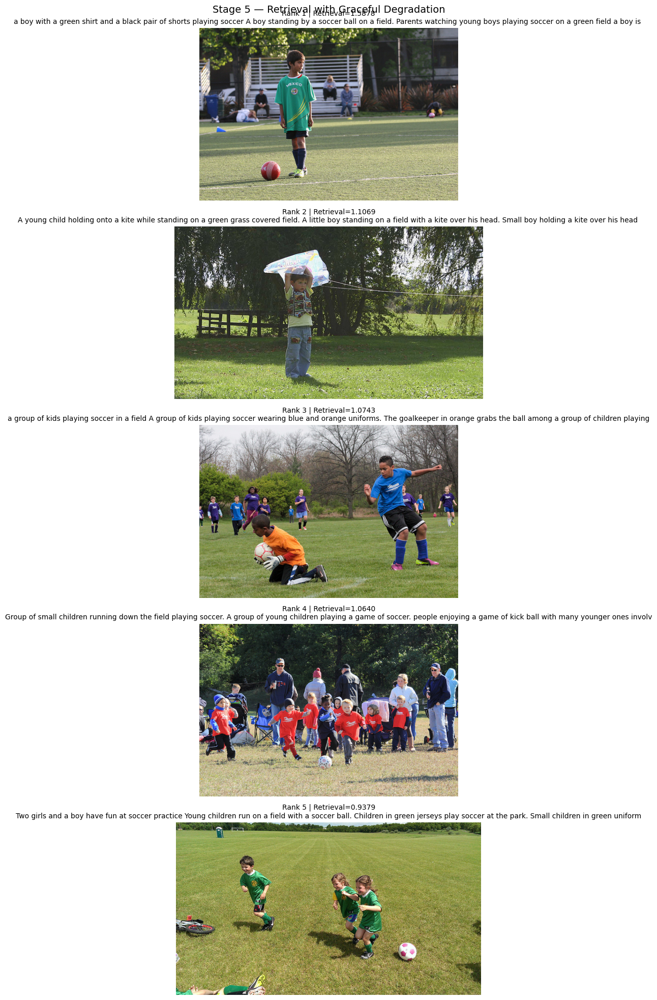

Trace: [('reranked', 0.5817983150482178)]


In [46]:
#Fallback demo
fallback_demo, fallback_trace = retrieve_with_fallback(demo_query, top_k=5)
show_image_results(fallback_demo, title="Stage 5 — Retrieval with Graceful Degradation")
print("Trace:", fallback_trace)

In [48]:
#Stage 5 eval
def fallback_pred_ids(query, top_k=5):
    results, _ = retrieve_with_fallback(query, top_k=top_k)
    return [r["image_id"] for r in results]

stage5_metrics = evaluate_system(eval_df, fallback_pred_ids, top_k=TOP_K_EVAL, n_samples=EVAL_SAMPLES)
stage5_metrics

Evaluating:   0%|          | 0/300 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

...

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

{'recall@1': 0.9633333333333334,
 'recall@5': 0.9833333333333333,
 'mrr': 0.9716666666666667,
 'precision@5': 0.19666666666666666,
 'ndcg@5': 0.974616907101442,
 'latency_median_sec': 0.6324154138565063,
 'latency_mean_sec': 0.6336644848187765,
 'num_samples': 300}

## Stage 6 — LangChain RAG + OpenAI Scene Explanation

In this stage we convert the manual retrieval-to-generation flow into a LangChain RAG pipeline.

Pipeline:
1. Retrieve evidence captions
2. Build grounded context
3. Send query + evidence to OpenAI through LangChain
4. Generate scene explanation

Optional:
- lightweight tool-based agent wrapper

In [49]:
#OpenAI client
openai_client = None
llm = None

if OPENAI_API_KEY:
    openai_client = OpenAI(api_key=OPENAI_API_KEY)
    llm = ChatOpenAI(
        model=OPENAI_MODEL,
        temperature=0.2,
        api_key=OPENAI_API_KEY
    )
    print("OpenAI SDK client ready")
    print("LangChain ChatOpenAI ready")
else:
    print("No OPENAI_API_KEY found. LangChain/OpenAI explanation stage will be skipped.")

OpenAI SDK client ready
LangChain ChatOpenAI ready


In [50]:
#REASONING HELPERS
import base64
import json
import mimetypes
import re

def encode_image_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def guess_mime_type(image_path):
    mime, _ = mimetypes.guess_type(str(image_path))
    return mime or "image/jpeg"

def parse_audit_json(text):
    """
    Robust parser for GPT output.
    Expected JSON:
    {
      "verdict": "match" | "weak_match" | "reject",
      "score": 0-10,
      "reason": "..."
    }
    """
    try:
        data = json.loads(text)
        return {
            "verdict": str(data.get("verdict", "unknown")).strip().lower(),
            "score": float(data.get("score", 0.0)),
            "reason": str(data.get("reason", "")).strip()
        }
    except Exception:
        verdict = "unknown"
        score = 0.0
        reason = text.strip()

        v = re.search(r'verdict\s*[:=]\s*"?([a-z_]+)"?', text, re.I)
        s = re.search(r'score\s*[:=]\s*([0-9]+(?:\.[0-9]+)?)', text, re.I)

        if v:
            verdict = v.group(1).strip().lower()
        if s:
            score = float(s.group(1))

        return {
            "verdict": verdict,
            "score": score,
            "reason": reason
        }

In [51]:
#VISUAL AUDITOR
def visual_auditor(query, retrieved_results, top_k=3, model=OPENAI_MODEL):
    """
    Uses GPT-4o-mini Vision to verify whether the top retrieved images
    actually satisfy the user query. Returns re-ranked results.
    """
    if openai_client is None:
        print("OpenAI client not available. Returning original results.")
        return retrieved_results

    if not retrieved_results:
        return retrieved_results

    audited = []

    for r in retrieved_results[:top_k]:
        image_path = r["image_path"]
        caption = r.get("caption", "")
        mime_type = guess_mime_type(image_path)
        image_b64 = encode_image_base64(image_path)

        prompt = f"""
You are a strict multimodal retrieval auditor.

User query:
{query}

Retrieved caption:
{caption}

Task:
Evaluate whether the ACTUAL IMAGE satisfies the query.

Rules:
- Focus on fine-grained attributes if present (color, count, action, object, scene).
- Do not assume the caption is correct; inspect the image.
- Be conservative. If an important detail is missing, lower the score.
- Return ONLY valid JSON.

Return exactly this schema:
{{
  "verdict": "match" | "weak_match" | "reject",
  "score": 0-10,
  "reason": "short explanation"
}}
"""

        response = openai_client.chat.completions.create(
            model=model,
            temperature=0,
            messages=[
                {
                    "role": "system",
                    "content": "You verify whether a retrieved image truly satisfies a query."
                },
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {
                            "type": "image_url",
                            "image_url": {"url": f"data:{mime_type};base64,{image_b64}"}
                        }
                    ]
                }
            ],
            max_tokens=120
        )

        raw_text = response.choices[0].message.content.strip()
        parsed = parse_audit_json(raw_text)

        new_r = dict(r)
        new_r["audit_score"] = parsed["score"]
        new_r["audit_verdict"] = parsed["verdict"]
        new_r["audit_reason"] = parsed["reason"]
        audited.append(new_r)

    # keep the rest unchanged if top_k < len(retrieved_results)
    remainder = [dict(x) for x in retrieved_results[top_k:]]

    audited.sort(key=lambda x: x.get("audit_score", 0), reverse=True)

    final_results = audited + remainder

    # reset rank
    for idx, item in enumerate(final_results, start=1):
        item["rank"] = idx

    return final_results

In [52]:
def retrieve_with_visual_audit(query, top_k=5, audit_top_k=3):
    results, trace = retrieve_with_fallback(query, top_k=top_k)
    audited_results = visual_auditor(query, results, top_k=audit_top_k)
    return audited_results, trace

In [ ]:
!pip install -q langchain-core langchain-openai

In [ ]:
from langchain_core.prompts import PromptTemplate
print("LangChain working")

In [53]:
# -------------------------------------------------------
# Cell 53 — LangChain Few-Shot Prompt Template for RAG
# -------------------------------------------------------

from langchain_core.prompts import PromptTemplate

scene_prompt = PromptTemplate(
    input_variables=["query", "context"],
    template="""
You are a grounded scene explanation assistant.

Use ONLY the evidence captions to explain the scene.
Do not invent information that is not present in the evidence.

Example 1
Query: people skiing on a mountain
Evidence:
1. several skiers descend a snowy mountain slope
2. people skiing on snow in the mountains
3. a group of skiers moving downhill
Answer:
The scene shows people skiing on a snowy mountain slope. It is an outdoor winter sports scene.

Example 2
Query: dog running through a park
Evidence:
1. a brown dog runs across a grassy field
2. a dog is sprinting over grass
3. a dog running outdoors in a park area
Answer:
The scene shows a dog running outdoors across a grassy park or field.

Now answer the following.

Query:
{query}

Evidence:
{context}

Answer:
"""
)

In [54]:
#OpenAI explanation function
# OpenAI explanation function (audit + explanation)
def generate_scene_explanation_openai(query, retrieved_results, model=OPENAI_MODEL, audit_top_k=3):
    if openai_client is None:
        return "OPENAI_API_KEY not found. Skipping OpenAI scene explanation."

    audited_results = visual_auditor(query, retrieved_results, top_k=audit_top_k)
    context = format_retrieved_context(audited_results, top_n=3)

    prompt = f"""
You are a grounded scene explanation assistant.

User query:
{query}

Retrieved evidence:
{context}

Task:
- Explain what the best matching image(s) show.
- Prefer high-audit-score evidence.
- If the evidence is weak or partially matching, say so clearly.
- Do not invent unsupported details.
"""

    response = openai_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "You generate concise, grounded scene explanations."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.2,
        max_tokens=140
    )
    return response.choices[0].message.content.strip()

In [55]:
#CELL 55 — Lightweight agent/tool orchestration
@tool
def retrieve_images_tool(query: str) -> str:
    """Retrieve top images and captions relevant to a text query."""
    results, trace = retrieve_with_visual_audit(query, top_k=5, audit_top_k=3)
    lines = []
    for r in results:
        lines.append(
            f"Rank {r['rank']} | image_id={r['image_id']} | "
            f"audit_score={r.get('audit_score', 'NA')} | "
            f"verdict={r.get('audit_verdict', 'NA')} | "
            f"caption={r['caption'][:180]}"
        )
    return "\n".join(lines)

@tool
def retrieve_captions_tool(query: str) -> str:
    """Retrieve grounded caption evidence for a query."""
    results, trace = retrieve_with_visual_audit(query, top_k=5, audit_top_k=3)
    return format_retrieved_context(results, top_n=3)

@tool
def explain_scene_tool(query: str) -> str:
    """Verify retrieved images and generate a grounded explanation."""
    results, trace = retrieve_with_fallback(query, top_k=5)
    return generate_scene_explanation_openai(query, results)
  

In [56]:
# -------------------------------------------------------
# Format retrieved captions into RAG context
# -------------------------------------------------------
def format_retrieved_context(retrieved_results, top_n=3):
    context_lines = []

    for i, r in enumerate(retrieved_results[:top_n]):
        caption = r["caption"]
        audit_score = r.get("audit_score", None)
        audit_verdict = r.get("audit_verdict", None)

        extra = ""
        if audit_score is not None:
            extra = f" | audit_score={audit_score:.1f}"
        if audit_verdict is not None:
            extra += f" | verdict={audit_verdict}"

        context_lines.append(f"{i+1}. {caption[:220]}{extra}")

    return "\n".join(context_lines)

In [57]:
# -------------------------------------------------------
# LangChain RAG Chain
# -------------------------------------------------------

from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# Initialize LLM
if OPENAI_API_KEY:
    llm = ChatOpenAI(
        model=OPENAI_MODEL,
        temperature=0.2,
        api_key=OPENAI_API_KEY
    )
else:
    llm = None

# Build RAG chain
if llm is not None:
    rag_chain = (
        RunnablePassthrough()
        | scene_prompt
        | llm
        | StrOutputParser()
    )
else:
    rag_chain = None

In [58]:
# -------------------------------------------------------
# Generate scene explanation using LangChain + OpenAI
# -------------------------------------------------------
def generate_scene_explanation_rag(query, retrieved_results):
    context = format_retrieved_context(retrieved_results, top_n=3)

    if llm is None:
        return "OpenAI key not found. Skipping explanation."

    explanation = rag_chain.invoke({
        "query": query,
        "context": context
    })

    return explanation

In [59]:
def build_scene_explanation_prompt(query, retrieved_results):
    evidence = "\n".join(
        [f"{i+1}. {r['caption'][:220]}" for i, r in enumerate(retrieved_results[:3])]
    )

    prompt = f"""
You are a grounded scene explanation assistant.
Use only the retrieved evidence below.

Example 1
Query: people skiing on a mountain
Evidence:
1. several skiers descend a snowy mountain slope
2. people skiing on snow in the mountains
3. a group of skiers moving downhill
Answer:
The scene shows people skiing on a snowy mountain slope. It is an outdoor winter sports scene.

Example 2
Query: dog running through a park
Evidence:
1. a brown dog runs across a grassy field
2. a dog is sprinting over grass
3. a dog running outdoors in a park area
Answer:
The scene shows a dog running outdoors across a grassy park or field. It appears to be an active outdoor scene.

Now answer the following.

Query: {query}
Evidence:
{evidence}
Answer:
"""
    return prompt.strip()

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

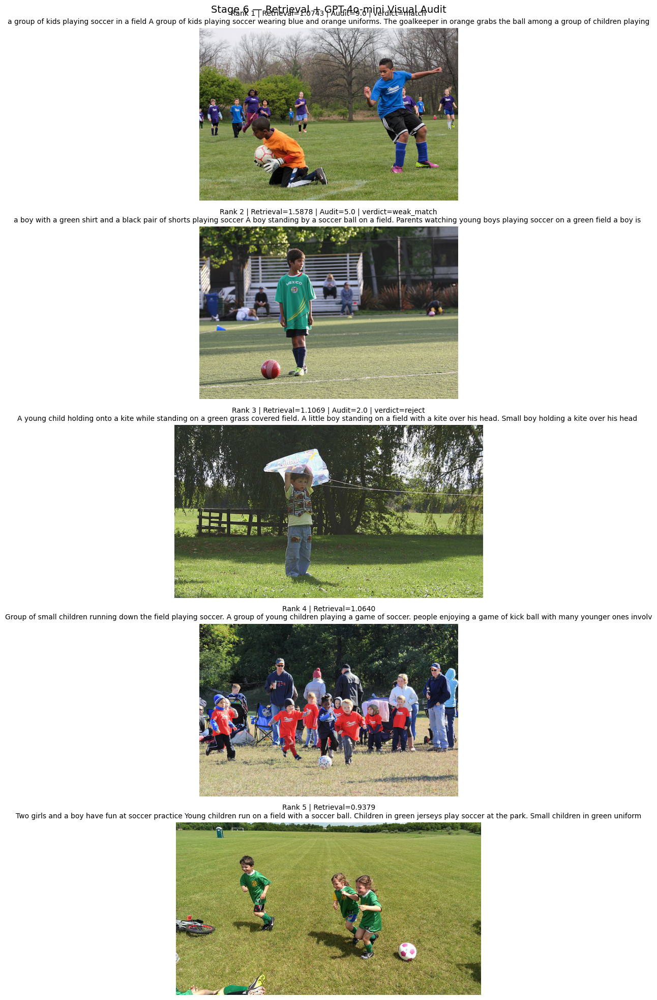

Trace: [('reranked', 0.6459746360778809)]

Retrieved Context After Audit:

1. a group of kids playing soccer in a field A group of kids playing soccer wearing blue and orange uniforms. The goalkeeper in orange grabs the ball among a group of children playing soccer. A little boy grips a soccer bal | audit_score=9.0 | verdict=match
2. a boy with a green shirt and a black pair of shorts playing soccer A boy standing by a soccer ball on a field. Parents watching young boys playing soccer on a green field a boy is standing next to a red ball outside a yo | audit_score=5.0 | verdict=weak_match
3. A young child holding onto a kite while standing on a green grass covered field. A little boy standing on a field with a kite over his head. Small boy holding a kite over his head waiting. A child standing outdoors in th | audit_score=2.0 | verdict=reject

Audit Details:

Rank 1 | audit_score=9.0 | verdict=match
The image shows children playing soccer outdoors, with clear action and appropriate uni

In [60]:
# Stage 6 demo with Visual Auditor
query_demo = demo_query

results_demo, trace_demo = retrieve_with_fallback(query_demo, top_k=5)
audited_demo = visual_auditor(query_demo, results_demo, top_k=3)

show_image_results(audited_demo, title="Stage 6 — Retrieval + GPT-4o-mini Visual Audit")
print("Trace:", trace_demo)

print("\nRetrieved Context After Audit:\n")
print(format_retrieved_context(audited_demo, top_n=3))

print("\nAudit Details:\n")
for r in audited_demo[:3]:
    print(f"Rank {r['rank']} | audit_score={r.get('audit_score', 'NA')} | verdict={r.get('audit_verdict', 'NA')}")
    print(r.get("audit_reason", ""))
    print("-" * 80)

print("\nLangChain RAG Explanation After Audit:\n")
print(generate_scene_explanation_rag(query_demo, audited_demo))

print("\nDirect OpenAI Explanation After Audit:\n")
print(generate_scene_explanation_openai(query_demo, results_demo))

In [61]:
#Image-input agent demo
image_demo_results = retrieve_image_to_text(sample_img, top_k=3)

print("Top retrieved captions from image:\n")
for r in image_demo_results:
    print(f"Rank {r['rank']} | Score={r['score']:.4f}")
    print(r["caption"][:220])
    print("-" * 80)

pseudo_query = "Explain the scene shown in this image."

print("\nLangChain RAG Explanation from retrieved image evidence:\n")
print(generate_scene_explanation_rag(pseudo_query, image_demo_results))

Encoding images:   0%|          | 0/1 [00:00<?, ?it/s]

Top retrieved captions from image:

Rank 1 | Score=0.2730
A beautiful woman taking a picture with her smart phone. People underneath an arched bridge near the water. A girl is taking a picture of people fishing. The woman is taking a photo of the white goose next to the river. 
--------------------------------------------------------------------------------
Rank 2 | Score=0.2264
A swan in the water near a boat tied to a dock. A white swan swimming through a lake next to a boat. Swan floating on a river in front of a boat. A white duck is swimming in the water near a boat. A white swan is swimmin
--------------------------------------------------------------------------------
Rank 3 | Score=0.2058
A woman taking pictures on a busy street. A woman taking a picture on a sunny day. A male and a female holding up their cellphones A woman taking a picture up at the sky with her phone. A woman holding a camera is taking
-------------------------------------------------------------------------

In [62]:
# Stage 6 latency breakdown on one query
def latency_breakdown(query, top_k=5):
    breakdown = {}

    start = time.time()
    q_emb = encode_texts([query], batch_size=1)[0]
    breakdown["query_encoding_sec"] = time.time() - start

    start = time.time()
    dense_scores = image_embs @ q_emb
    _ = np.argsort(-dense_scores)[:50]
    breakdown["dense_retrieval_sec"] = time.time() - start

    start = time.time()
    _ = bm25.get_scores(bm25_tokenize(query))
    breakdown["bm25_sec"] = time.time() - start

    start = time.time()
    _ = retrieve_text_to_image_hybrid(query, top_k=top_k, candidate_k=30)
    breakdown["hybrid_total_sec"] = time.time() - start

    start = time.time()
    reranked_results = retrieve_text_to_image_reranked(query, top_k=top_k, candidate_k=30)
    breakdown["rerank_total_sec"] = time.time() - start

    if openai_client is not None:
        start = time.time()
        audited_results = visual_auditor(query, reranked_results, top_k=min(3, len(reranked_results)))
        breakdown["multimodal_visual_audit_sec"] = time.time() - start

        start = time.time()
        _ = generate_scene_explanation_rag(query, audited_results)
        breakdown["rag_explanation_after_audit_sec"] = time.time() - start
    else:
        breakdown["multimodal_visual_audit_sec"] = None
        breakdown["rag_explanation_after_audit_sec"] = None

    return breakdown

latency_demo = latency_breakdown(demo_query, top_k=5)
latency_demo

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

{'query_encoding_sec': 0.5741260051727295,
 'dense_retrieval_sec': 0.0015647411346435547,
 'bm25_sec': 0.010696649551391602,
 'hybrid_total_sec': 0.5963592529296875,
 'rerank_total_sec': 0.6477313041687012,
 'multimodal_visual_audit_sec': 8.945170402526855,
 'rag_explanation_after_audit_sec': 1.8776323795318604}

## Stage 7 — Final comparison table

We compare the main retrieval stages:

- Stage 1: Plain dense
- Stage 2: Dense via persistent system
- Stage 3: Hybrid
- Stage 4: Hybrid + reranking
- Stage 5: Fallback pipeline

In [63]:
metrics_df = pd.DataFrame([
    {"stage": "stage1_plain_dense", **stage1_metrics},
    {"stage": "stage2_cached_persistent_dense", **stage2_metrics},
    {"stage": "stage3_hybrid", **stage3_metrics},
    {"stage": "stage4_hybrid_reranked", **stage4_metrics},
    {"stage": "stage5_fallback_pipeline", **stage5_metrics},
])

metrics_df

,stage,recall@1,recall@5,mrr,precision@5,ndcg@5,latency_median_sec,latency_mean_sec,num_samples
0,stage1_plain_dense,0.366667,0.646667,0.473778,0.129333,0.517058,0.436671,0.435820,300
1,stage2_cached_persistent_dense,0.363333,0.643333,0.470611,0.128667,0.513871,0.432087,0.432250,300
2,stage3_hybrid,0.800000,0.916667,0.845056,0.183333,0.863004,0.494214,0.494437,300
3,stage4_hybrid_reranked,0.963333,0.983333,0.971667,0.196667,0.974617,0.586464,0.585134,300
4,stage5_fallback_pipeline,0.963333,0.983333,0.971667,0.196667,0.974617,0.632415,0.633664,300


In [64]:
metrics_csv_path = RESULTS_DIR / "metrics_summary.csv"
metrics_df.to_csv(metrics_csv_path, index=False)
print("Saved:", metrics_csv_path)

Saved: results/metrics_summary.csv


In [65]:
base_row = metrics_df[metrics_df["stage"] == "stage1_plain_dense"].iloc[0]
improvement_df = metrics_df.copy()

for col in ["recall@1", "recall@5", "mrr", "precision@5", "ndcg@5"]:
    improvement_df[f"{col}_gain_vs_plain"] = improvement_df[col] - base_row[col]

improvement_df

,stage,recall@1,recall@5,mrr,precision@5,ndcg@5,latency_median_sec,latency_mean_sec,num_samples,recall@1_gain_vs_plain,recall@5_gain_vs_plain,mrr_gain_vs_plain,precision@5_gain_vs_plain,ndcg@5_gain_vs_plain
0,stage1_plain_dense,0.366667,0.646667,0.473778,0.129333,0.517058,0.436671,0.435820,300,0.000000,0.000000,0.000000,0.000000,0.000000
1,stage2_cached_persistent_dense,0.363333,0.643333,0.470611,0.128667,0.513871,0.432087,0.432250,300,-0.003333,-0.003333,-0.003167,-0.000667,-0.003187
2,stage3_hybrid,0.800000,0.916667,0.845056,0.183333,0.863004,0.494214,0.494437,300,0.433333,0.270000,0.371278,0.054000,0.345946
3,stage4_hybrid_reranked,0.963333,0.983333,0.971667,0.196667,0.974617,0.586464,0.585134,300,0.596667,0.336667,0.497889,0.067333,0.457559
4,stage5_fallback_pipeline,0.963333,0.983333,0.971667,0.196667,0.974617,0.632415,0.633664,300,0.596667,0.336667,0.497889,0.067333,0.457559


In [67]:
import os
import json
import pickle
import shutil
from pathlib import Path

EXPORT_DIR = Path("/kaggle/working/scene_search_demo_artifacts")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Save embeddings
np.save(EXPORT_DIR / "image_embs.npy", image_embs)
np.save(EXPORT_DIR / "text_embs.npy", text_embs)

# Save metadata arrays
with open(EXPORT_DIR / "image_ids.pkl", "wb") as f:
    pickle.dump(image_ids, f)

with open(EXPORT_DIR / "image_paths.pkl", "wb") as f:
    pickle.dump(image_paths, f)

with open(EXPORT_DIR / "image_texts.pkl", "wb") as f:
    pickle.dump(image_texts, f)

# Save config
artifact_meta = {
    "CLIP_MODEL_NAME": CLIP_MODEL_NAME,
    "CLIP_PRETRAINED": CLIP_PRETRAINED,
    "RERANK_MODEL_NAME": RERANK_MODEL_NAME,
    "OPENAI_MODEL": OPENAI_MODEL,
    "TOP_K_EVAL": TOP_K_EVAL
}
with open(EXPORT_DIR / "artifact_meta.json", "w") as f:
    json.dump(artifact_meta, f, indent=2)

print("Artifacts saved to:", EXPORT_DIR)

Artifacts saved to: /kaggle/working/scene_search_demo_artifacts


## Stage 8 — Final plots

We plot:
- Recall@1
- Recall@5
- MRR
- Precision@5
- nDCG@5
- Latency
- Gain vs baseline

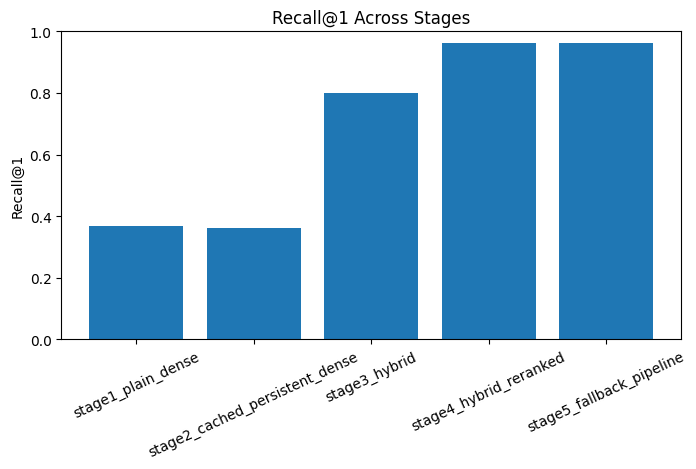

In [68]:
#Recall@1 plot
plt.figure(figsize=(8, 4))
plt.bar(metrics_df["stage"], metrics_df["recall@1"])
plt.title("Recall@1 Across Stages")
plt.ylabel("Recall@1")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.show()

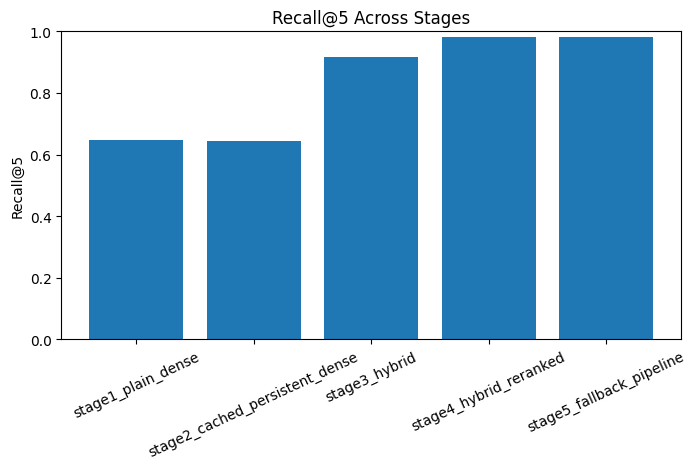

In [69]:
#Recall@5 plot
plt.figure(figsize=(8, 4))
plt.bar(metrics_df["stage"], metrics_df["recall@5"])
plt.title("Recall@5 Across Stages")
plt.ylabel("Recall@5")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.show()

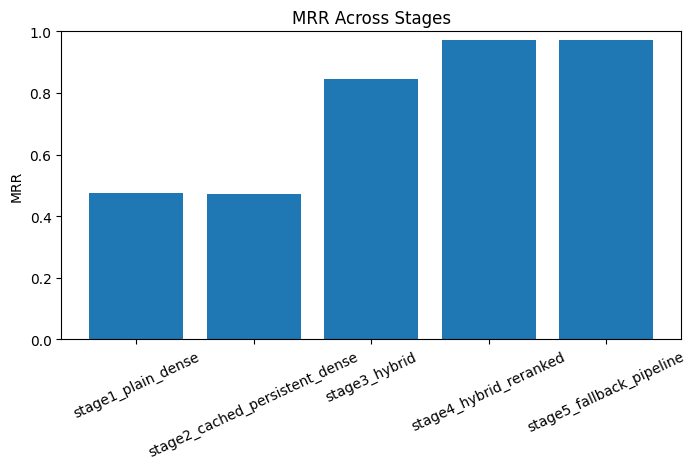

In [70]:
#MRR plot
plt.figure(figsize=(8, 4))
plt.bar(metrics_df["stage"], metrics_df["mrr"])
plt.title("MRR Across Stages")
plt.ylabel("MRR")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.show()

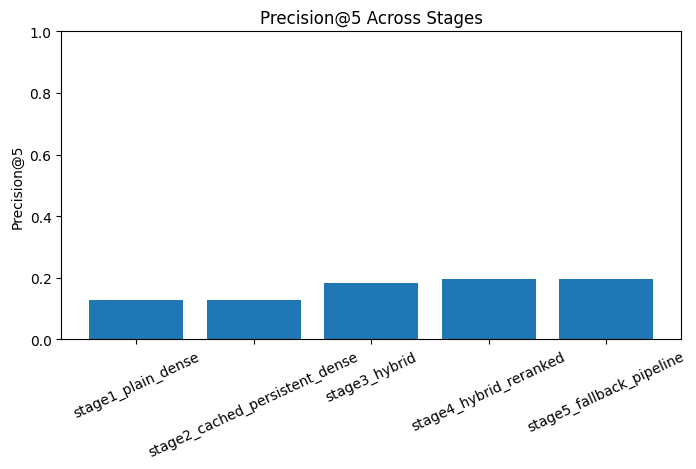

In [71]:
#Precision@5 plot
plt.figure(figsize=(8, 4))
plt.bar(metrics_df["stage"], metrics_df["precision@5"])
plt.title("Precision@5 Across Stages")
plt.ylabel("Precision@5")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.show()

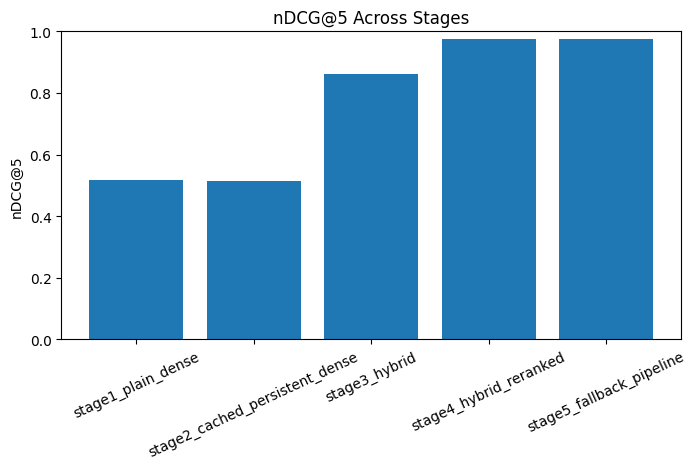

In [72]:
#nDCG@5 plot
plt.figure(figsize=(8, 4))
plt.bar(metrics_df["stage"], metrics_df["ndcg@5"])
plt.title("nDCG@5 Across Stages")
plt.ylabel("nDCG@5")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.show()

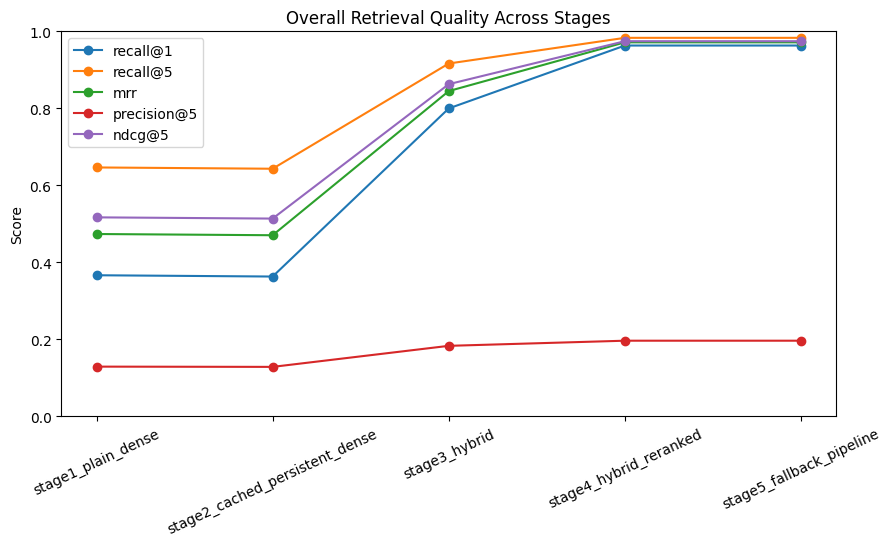

In [73]:
#Combined quality plot
plot_df = metrics_df.set_index("stage")[["recall@1", "recall@5", "mrr", "precision@5", "ndcg@5"]]

plt.figure(figsize=(10, 5))
for col in plot_df.columns:
    plt.plot(plot_df.index, plot_df[col], marker="o", label=col)

plt.title("Overall Retrieval Quality Across Stages")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.legend()
plt.show()

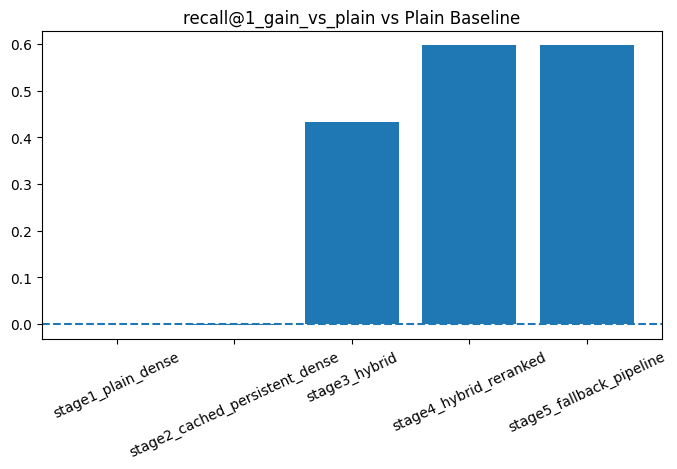

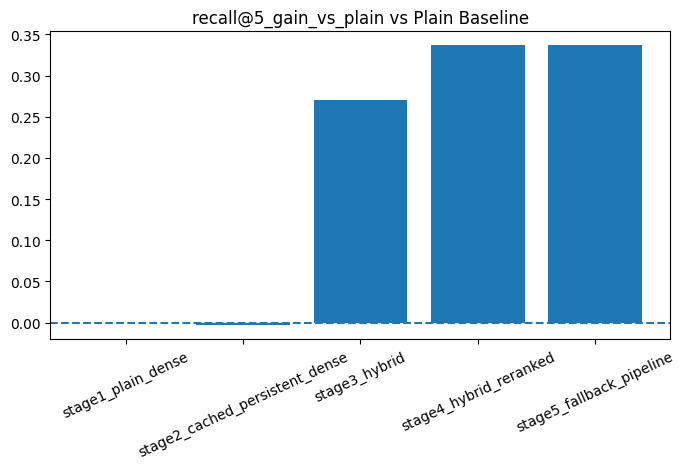

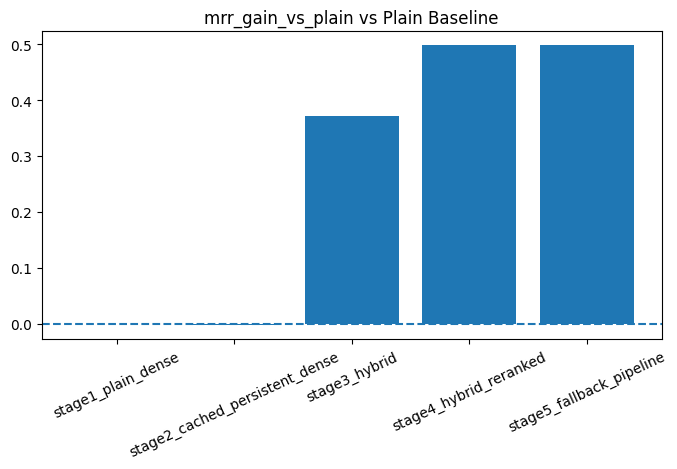

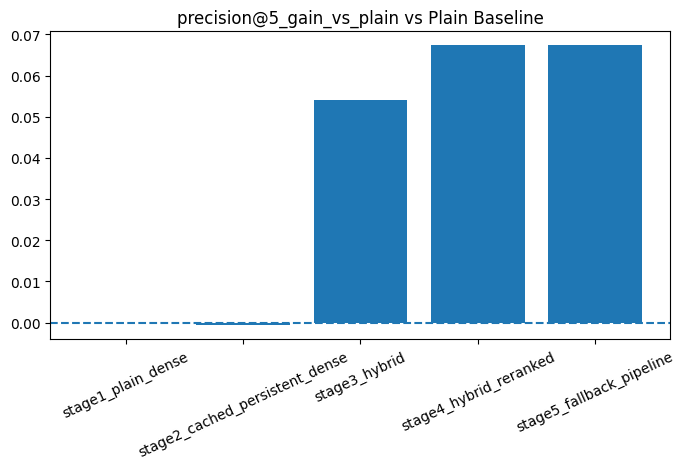

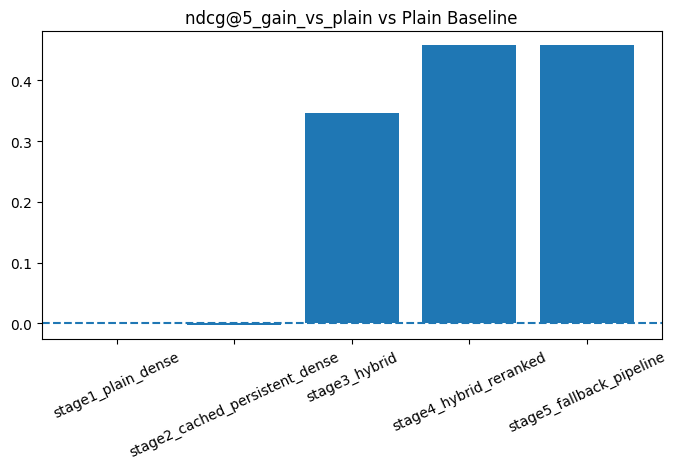

In [74]:
#Gain plots vs baseline
gain_cols = [
    "recall@1_gain_vs_plain",
    "recall@5_gain_vs_plain",
    "mrr_gain_vs_plain",
    "precision@5_gain_vs_plain",
    "ndcg@5_gain_vs_plain"
]

for col in gain_cols:
    plt.figure(figsize=(8, 4))
    plt.bar(improvement_df["stage"], improvement_df[col])
    plt.title(f"{col} vs Plain Baseline")
    plt.axhline(0, linestyle="--")
    plt.xticks(rotation=25)
    plt.show()

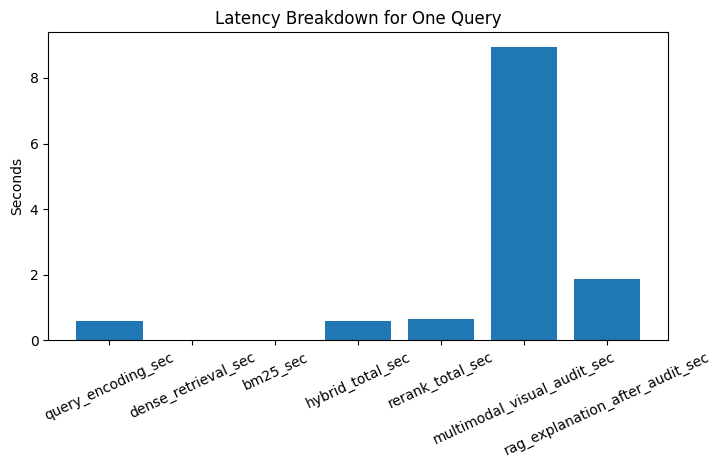

In [75]:
#Latency breakdown plot for one query
latency_keys = [k for k, v in latency_demo.items() if v is not None]
latency_vals = [latency_demo[k] for k in latency_keys]

plt.figure(figsize=(8, 4))
plt.bar(latency_keys, latency_vals)
plt.title("Latency Breakdown for One Query")
plt.ylabel("Seconds")
plt.xticks(rotation=25)
plt.show()

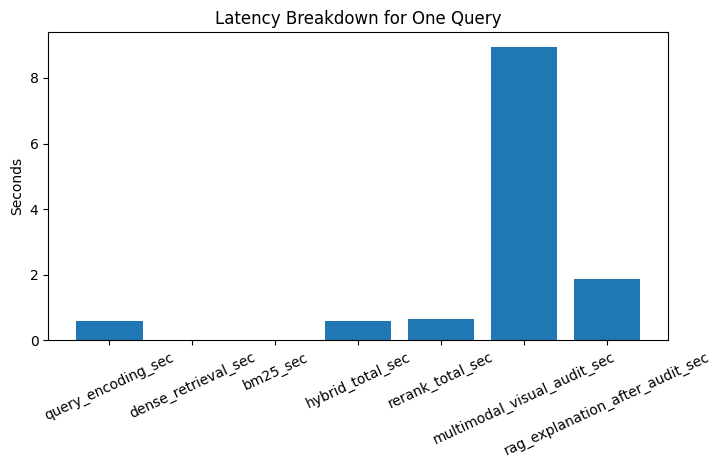

In [76]:
#Latency breakdown plot for one query
latency_keys = [k for k, v in latency_demo.items() if v is not None]
latency_vals = [latency_demo[k] for k in latency_keys]

plt.figure(figsize=(8, 4))
plt.bar(latency_keys, latency_vals)
plt.title("Latency Breakdown for One Query")
plt.ylabel("Seconds")
plt.xticks(rotation=25)
plt.show()

In [77]:
#Side-by-side qualitative comparison
compare_queries = [
    "children playing football outdoors",
    "a dog running through grass",
    "people riding bicycles on a street"
]

for q in compare_queries:
    print("=" * 120)
    print("QUERY:", q)

    plain = retrieve_text_to_image_plain(q, top_k=1)
    hybrid = retrieve_text_to_image_hybrid(q, top_k=1)
    reranked = retrieve_text_to_image_reranked(q, top_k=1)

    print("\n[PLAIN]")
    print(plain[0]["caption"][:220])

    print("\n[HYBRID]")
    print(hybrid[0]["caption"][:220])

    print("\n[RERANKED]")
    print(reranked[0]["caption"][:220])

    if openai_client is not None:
        explanation = generate_scene_explanation_openai(q, reranked)
        print("\n[OPENAI SCENE EXPLANATION]")
        print(explanation)

QUERY: children playing football outdoors


Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]


[PLAIN]
Two boys are playing with a soccer ball. Two young boys kicking a soccer ball in a field. Two boys wearing different soccer uniforms are trying to kick a soccer ball. Two young boys kick a soccer ball on a soccer field B

[HYBRID]
Several children attentively play a game of curling together. Several children playing a game together outside with boats in the background. Young children playing game on wooden deck surface. a couple of kids playing a 

[RERANKED]
a boy with a green shirt and a black pair of shorts playing soccer A boy standing by a soccer ball on a field. Parents watching young boys playing soccer on a green field a boy is standing next to a red ball outside a yo

[OPENAI SCENE EXPLANATION]
The best matching evidence describes a scene where a boy in a green shirt and black shorts is playing soccer on a green field. There are also parents watching young boys playing soccer nearby. However, the match is considered weak, as the details provided do not fully capture t

...


[PLAIN]
A dog herding a group of sheep in a meadow Three sheep and a dog standing in a field. Three sheep running from a dog in the grass A flock of sheep in the field with grass a group of sheep in a field being followed by a d

[HYBRID]
A dog herding a group of sheep in a meadow Three sheep and a dog standing in a field. Three sheep running from a dog in the grass A flock of sheep in the field with grass a group of sheep in a field being followed by a d

[RERANKED]
A yellow dog runs to grab a yellow frisbee in the grass A dog is on the grass playing frisbee. A dog in the grass catching a frisbee. A tan dog leaping to catch a Frisbee A dog is opening his mouth to catch a Frisbee

[OPENAI SCENE EXPLANATION]
The best matching image shows a yellow dog running through grass, actively engaged in playing with a yellow frisbee. The dog is depicted leaping to catch the frisbee, with its mouth open in anticipation. This scene captures the playful and energetic nature of the dog as it enjoys i

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/1 [00:00<?, ?it/s]


[PLAIN]
Men on bikes riding alongside a car on the street Two men ride bikes next to the cars in the street. Two people are riding bikes through the street traffic. Several cars and people at bikes sitting at a red light. A stre

[HYBRID]
Men on bikes riding alongside a car on the street Two men ride bikes next to the cars in the street. Two people are riding bikes through the street traffic. Several cars and people at bikes sitting at a red light. A stre

[RERANKED]
A line of people are riding bicycles on the street. people riding bikes in a street next to a sidwalk There are people that are walking in a line A group of people on bicycles at a traffic light by vehicles. Bicycle ridi

[OPENAI SCENE EXPLANATION]
The best matching image shows a line of people riding bicycles on a street, positioned next to a sidewalk. The scene includes a group of cyclists at a traffic light, indicating they are waiting to cross or proceed alongside vehicles. There are also pedestrians walking in a line

# Final Summary

## What this system supports
- Text → Image retrieval
- Image → Image retrieval
- Image → Text evidence retrieval
- OpenAI-based scene explanation from retrieved evidence

## System-design improvements added layer by layer
1. Plain dense CLIP retrieval
2. Embedding caching
3. Persistent ChromaDB vector store
4. Hybrid retrieval (Dense + BM25)
5. Cross-encoder reranking
6. Graceful degradation / fallback pipeline
7. OpenAI scene explanation with few-shot prompting

## Main retrieval metrics tracked
- Recall@1
- Recall@5
- MRR
- Precision@5
- nDCG@5
- Median latency
- Mean latency

## Production-style features
- persistent vector storage
- fallback retrieval pipeline
- latency breakdown
- evidence-grounded explanation